# Portfolio Diversification Analyzer
### ML-Based Indian Equity Portfolio Analysis using K-Means Clustering + Sharpe Ratio Optimization

**Pipeline:**
1. Data Collection (yfinance — real-time NSE data)
2. Preprocessing & Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. K-Means Clustering (ML Model)
6. Portfolio Optimization (Sharpe Ratio)
7. Diversification Recommendations

---
## Block 1 — Install & Import Libraries

In [4]:
# Install required libraries (run once)
!pip install yfinance pyportfolioopt

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached pyportfolioopt-1.6.0-py3-none-any.whl.metadata (23 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached peewee-4.0.3-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
  Using cached scikit_base-0.13.1-py3-none-any.whl.metadata (8.8 kB)
  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached pyportfolioopt-1.6.0-py3-none-any.whl (67 kB)
Using cached scikit_bas

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('deep')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Block 2 — Define User Portfolio & Diversifier Pool

In [8]:
# ─── USER PORTFOLIO (simulating CSV upload) ────────────────────────────────
# In production, this comes from the uploaded CSV
user_portfolio = {
    'TCS.NS':     {'quantity': 10, 'buy_price': 3500},
    'INFY.NS':    {'quantity': 20, 'buy_price': 1500},
    'WIPRO.NS':   {'quantity': 15, 'buy_price':  450},
    'HCLTECH.NS': {'quantity':  8, 'buy_price': 1200},
}

# ─── DIVERSIFIER POOL (equity-only, different sectors) ─────────────────────
DIVERSIFIER_POOL = [
    'HINDUNILVR.NS',  # FMCG
    'NESTLEIND.NS',   # FMCG
    'SUNPHARMA.NS',   # Pharma
    'DRREDDY.NS',     # Pharma
    'BAJFINANCE.NS',  # Finance
    'HDFCBANK.NS',    # Banking
    'ONGC.NS',        # Energy / PSU
    'NTPC.NS',        # Power / PSU
    'TATASTEEL.NS',   # Metals
    'MARUTI.NS',      # Auto
    'TATAMOTORS.NS',  # Auto
    'ASIANPAINT.NS',  # Consumer
]

NEW_CASH = 50000          # Rupees user wants to invest
RISK_FREE_RATE = 0.07     # India SBI FD rate

# Compute invested value per stock
for sym, v in user_portfolio.items():
    v['invested'] = v['quantity'] * v['buy_price']

total_invested = sum(v['invested'] for v in user_portfolio.values())

portfolio_df = pd.DataFrame(user_portfolio).T.reset_index()
portfolio_df.columns = ['Symbol', 'Quantity', 'Buy Price', 'Invested Value']
portfolio_df['Weight %'] = (portfolio_df['Invested Value'] / total_invested * 100).round(2)

print(f'Total Portfolio Value: ₹{total_invested:,.0f}')
print(f'New Cash to Invest:    ₹{NEW_CASH:,.0f}')
print()
print(portfolio_df.to_string(index=False))

Total Portfolio Value: ₹81,350
New Cash to Invest:    ₹50,000

    Symbol  Quantity  Buy Price  Invested Value  Weight %
    TCS.NS        10       3500           35000     43.02
   INFY.NS        20       1500           30000     36.88
  WIPRO.NS        15        450            6750      8.30
HCLTECH.NS         8       1200            9600     11.80


---
## Block 3 — Data Collection (Live from NSE via yfinance)

In [9]:
# Combine user stocks + diversifier pool
all_symbols = list(set(user_portfolio.keys()) | set(DIVERSIFIER_POOL))
user_symbols = list(user_portfolio.keys())

print(f'Fetching 2 years of live NSE data for {len(all_symbols)} stocks...')
print('Symbols:', all_symbols)

raw_prices = yf.download(all_symbols, period='2y', auto_adjust=True, progress=True)['Close']

# Handle single stock edge case
if isinstance(raw_prices, pd.Series):
    raw_prices = raw_prices.to_frame(name=all_symbols[0])

print(f'\nData shape: {raw_prices.shape[0]} trading days x {raw_prices.shape[1]} stocks')
print(f'Date range: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}')
raw_prices.tail(3)

Fetching 2 years of live NSE data for 16 stocks...
Symbols: ['HDFCBANK.NS', 'ONGC.NS', 'HINDUNILVR.NS', 'TATAMOTORS.NS', 'DRREDDY.NS', 'WIPRO.NS', 'TCS.NS', 'ASIANPAINT.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'SUNPHARMA.NS', 'NTPC.NS', 'TATASTEEL.NS', 'INFY.NS', 'HCLTECH.NS']


[*********             19%                       ]  3 of 16 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  16 of 16 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")



Data shape: 495 trading days x 16 stocks
Date range: 2024-04-01 to 2026-03-30


Ticker,ASIANPAINT.NS,BAJFINANCE.NS,DRREDDY.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,MARUTI.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,SUNPHARMA.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,
2026-03-25,2270.199951,882.750000,1300.699951,1381.300049,782.299988,2134.800049,1279.099976,12711.0,1204.099976,378.399994,270.200012,1795.400024,NaN,196.649994,2377.399902,189.050003
2026-03-27,2207.399902,843.799988,1281.699951,1364.400024,756.200012,2074.399902,1269.699951,12389.0,1193.199951,375.649994,281.950012,1793.599976,NaN,193.220001,2389.800049,191.600006
2026-03-30,2174.000000,809.099976,1263.300049,1344.500000,735.750000,2054.699951,1251.000000,12379.0,1183.900024,374.750000,285.100006,1774.900024,NaN,193.710007,2358.600098,188.550003


---
## Block 4 — Data Preprocessing & Cleaning

In [10]:
# ── Step 1: Check missing data before cleaning ──────────────────────────────
missing_before = raw_prices.isnull().sum()
missing_pct_before = (raw_prices.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Days': missing_before,
    'Missing %': missing_pct_before
}).sort_values('Missing %', ascending=False)

print('Missing data BEFORE cleaning:')
print(missing_report[missing_report['Missing Days'] > 0].to_string())
print(f'\nTotal cells: {raw_prices.size}, Missing: {raw_prices.isnull().sum().sum()}')

Missing data BEFORE cleaning:
               Missing Days  Missing %
Ticker                                
TATAMOTORS.NS           495      100.0

Total cells: 7920, Missing: 495


In [11]:
# ── Step 2: Forward Fill (handle market holidays) ───────────────────────────
# If market is closed on a day, carry forward the last known price
prices_clean = raw_prices.ffill()

# Drop stocks where NO data was fetched (completely invalid tickers)
valid_cols_before = prices_clean.shape[1]
prices_clean = prices_clean.dropna(axis=1, how='all')
prices_clean = prices_clean.dropna(how='any')  # drop rows still missing
valid_cols_after = prices_clean.shape[1]

dropped = valid_cols_before - valid_cols_after
print(f'Stocks dropped (no data): {dropped}')
print(f'Stocks remaining: {valid_cols_after}')
print(f'Missing values after cleaning: {prices_clean.isnull().sum().sum()}')

# Update lists to only valid symbols
valid_user = [s for s in user_symbols if s in prices_clean.columns]
valid_pool = [s for s in DIVERSIFIER_POOL if s in prices_clean.columns]
valid_all = list(prices_clean.columns)

print(f'\nValid user stocks: {valid_user}')
prices_clean.tail(3)

Stocks dropped (no data): 1
Stocks remaining: 15
Missing values after cleaning: 0

Valid user stocks: ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS']


Ticker,ASIANPAINT.NS,BAJFINANCE.NS,DRREDDY.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,MARUTI.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,
2026-03-25,2270.199951,882.750000,1300.699951,1381.300049,782.299988,2134.800049,1279.099976,12711.0,1204.099976,378.399994,270.200012,1795.400024,196.649994,2377.399902,189.050003
2026-03-27,2207.399902,843.799988,1281.699951,1364.400024,756.200012,2074.399902,1269.699951,12389.0,1193.199951,375.649994,281.950012,1793.599976,193.220001,2389.800049,191.600006
2026-03-30,2174.000000,809.099976,1263.300049,1344.500000,735.750000,2054.699951,1251.000000,12379.0,1183.900024,374.750000,285.100006,1774.900024,193.710007,2358.600098,188.550003


In [12]:
# ── Step 3: Convert prices to daily % returns ───────────────────────────────
# Formula: (today_price - yesterday_price) / yesterday_price * 100
daily_returns = prices_clean.pct_change().dropna()

print(f'Daily Returns shape: {daily_returns.shape}')
print('\nSample daily returns (%):')
print((daily_returns[valid_user].head(5) * 100).round(3).to_string())

Daily Returns shape: (494, 15)

Sample daily returns (%):
Ticker      TCS.NS  INFY.NS  WIPRO.NS  HCLTECH.NS
Date                                             
2024-04-02  -0.841   -0.843    -0.773      -1.824
2024-04-03   1.635   -0.148     0.416       0.494
2024-04-04   1.419    0.409     0.869       0.247
2024-04-05  -0.601   -0.511    -0.482       0.364
2024-04-08  -0.168   -0.162    -1.062      -0.337


---
## Block 5 — EDA: Visualizing Raw Price Data

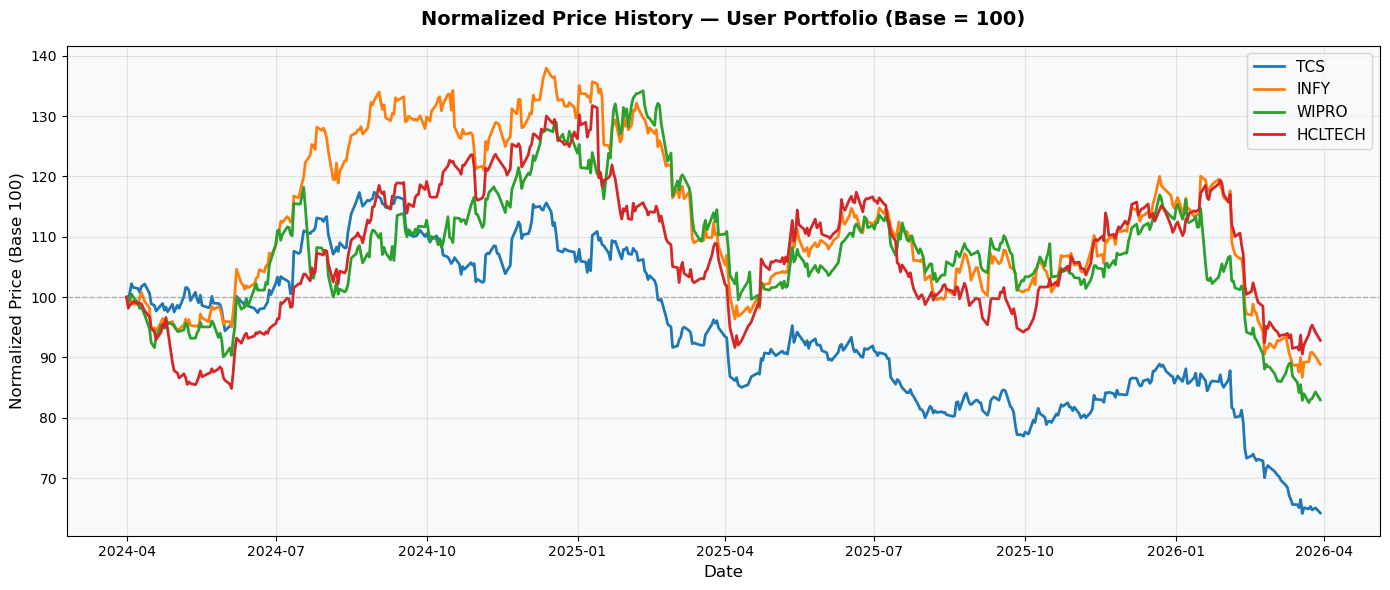

Observation: All IT stocks move very similarly — indicating HIGH correlation.


In [13]:
# ── Plot 1: Price History of User's Portfolio Stocks ────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, sym in enumerate(valid_user):
    norm = prices_clean[sym] / prices_clean[sym].iloc[0] * 100
    ax.plot(norm.index, norm.values,
            label=sym.replace('.NS', ''),
            color=colors[i % len(colors)],
            linewidth=2)

ax.set_title('Normalized Price History — User Portfolio (Base = 100)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (Base 100)', fontsize=12)
ax.legend(fontsize=11)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.show()
print('Observation: All IT stocks move very similarly — indicating HIGH correlation.')

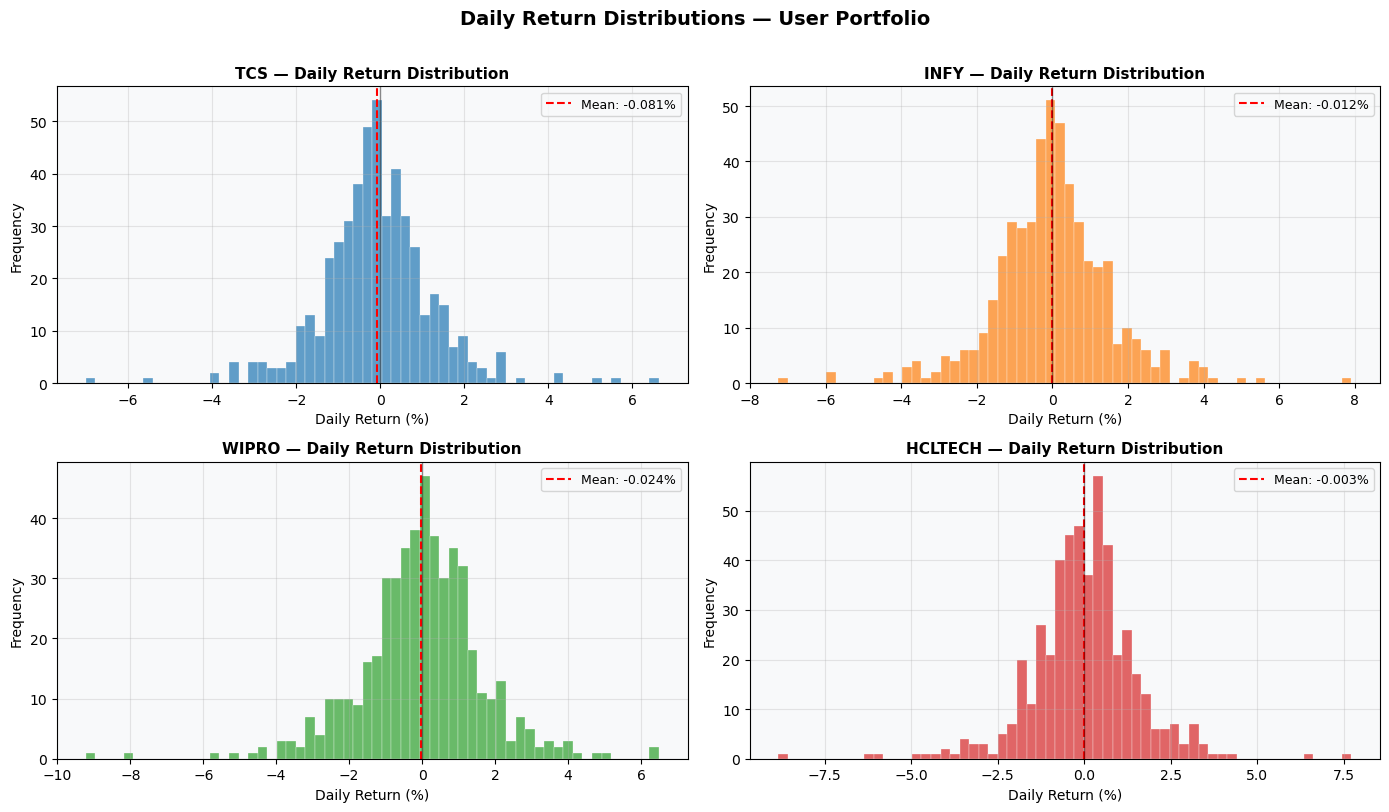

Observation: Bell-shaped distributions — returns follow roughly normal distribution.


In [14]:
# ── Plot 2: Daily Returns Distribution ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, sym in enumerate(valid_user[:4]):
    ret = daily_returns[sym] * 100
    ax = axes[i]
    ax.hist(ret, bins=60, color=colors[i], alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(ret.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {ret.mean():.3f}%')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.4)
    ax.set_title(f'{sym.replace(".NS", "")} — Daily Return Distribution', fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return (%)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Daily Return Distributions — User Portfolio', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Observation: Bell-shaped distributions — returns follow roughly normal distribution.')

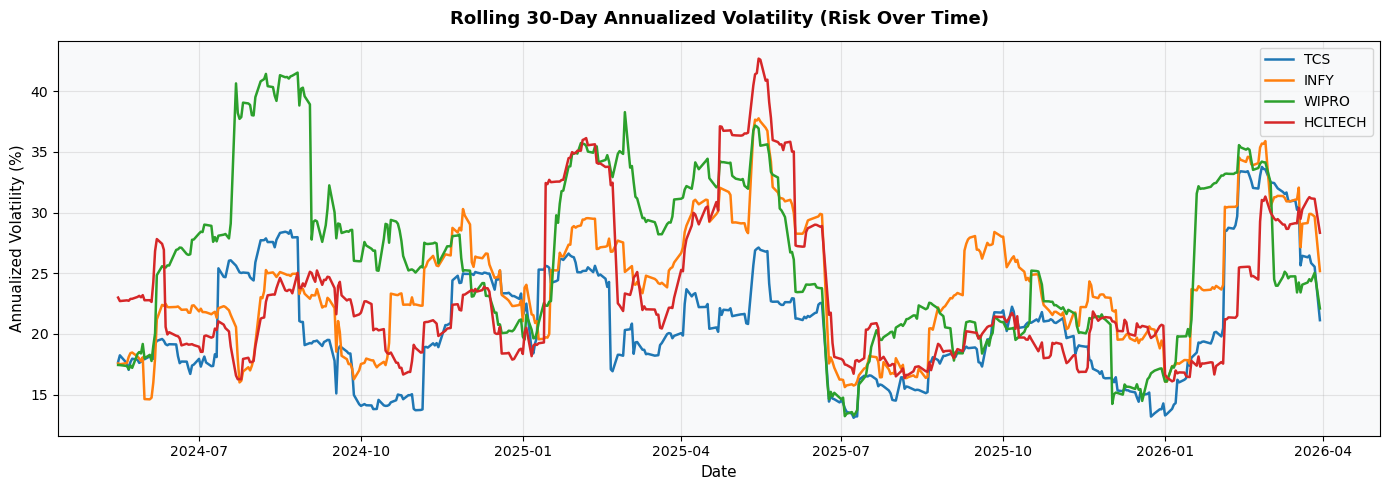

Observation: All 4 stocks spike and dip together — they share the same risk events.


In [15]:
# ── Plot 3: Rolling 30-Day Volatility ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for i, sym in enumerate(valid_user):
    roll_vol = daily_returns[sym].rolling(30).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values,
            label=sym.replace('.NS', ''),
            color=colors[i % len(colors)],
            linewidth=1.8)

ax.set_title('Rolling 30-Day Annualized Volatility (Risk Over Time)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility (%)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print('Observation: All 4 stocks spike and dip together — they share the same risk events.')

---
## Block 6 — EDA: Correlation Analysis

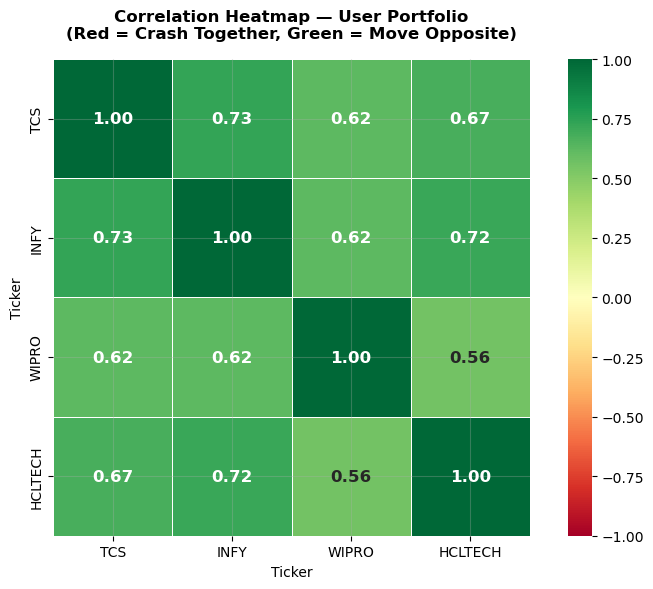

Problem detected: All correlations > 0.7 — portfolio has NO diversification!


In [16]:
# ── Plot 4: Correlation Heatmap — User Portfolio Only ───────────────────────
corr_user = daily_returns[valid_user].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_user, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # hide upper triangle duplicates... actually show full

sns.heatmap(
    corr_user,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    xticklabels=[s.replace('.NS','') for s in valid_user],
    yticklabels=[s.replace('.NS','') for s in valid_user],
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Correlation Heatmap — User Portfolio\n(Red = Crash Together, Green = Move Opposite)', 
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('Problem detected: All correlations > 0.7 — portfolio has NO diversification!')

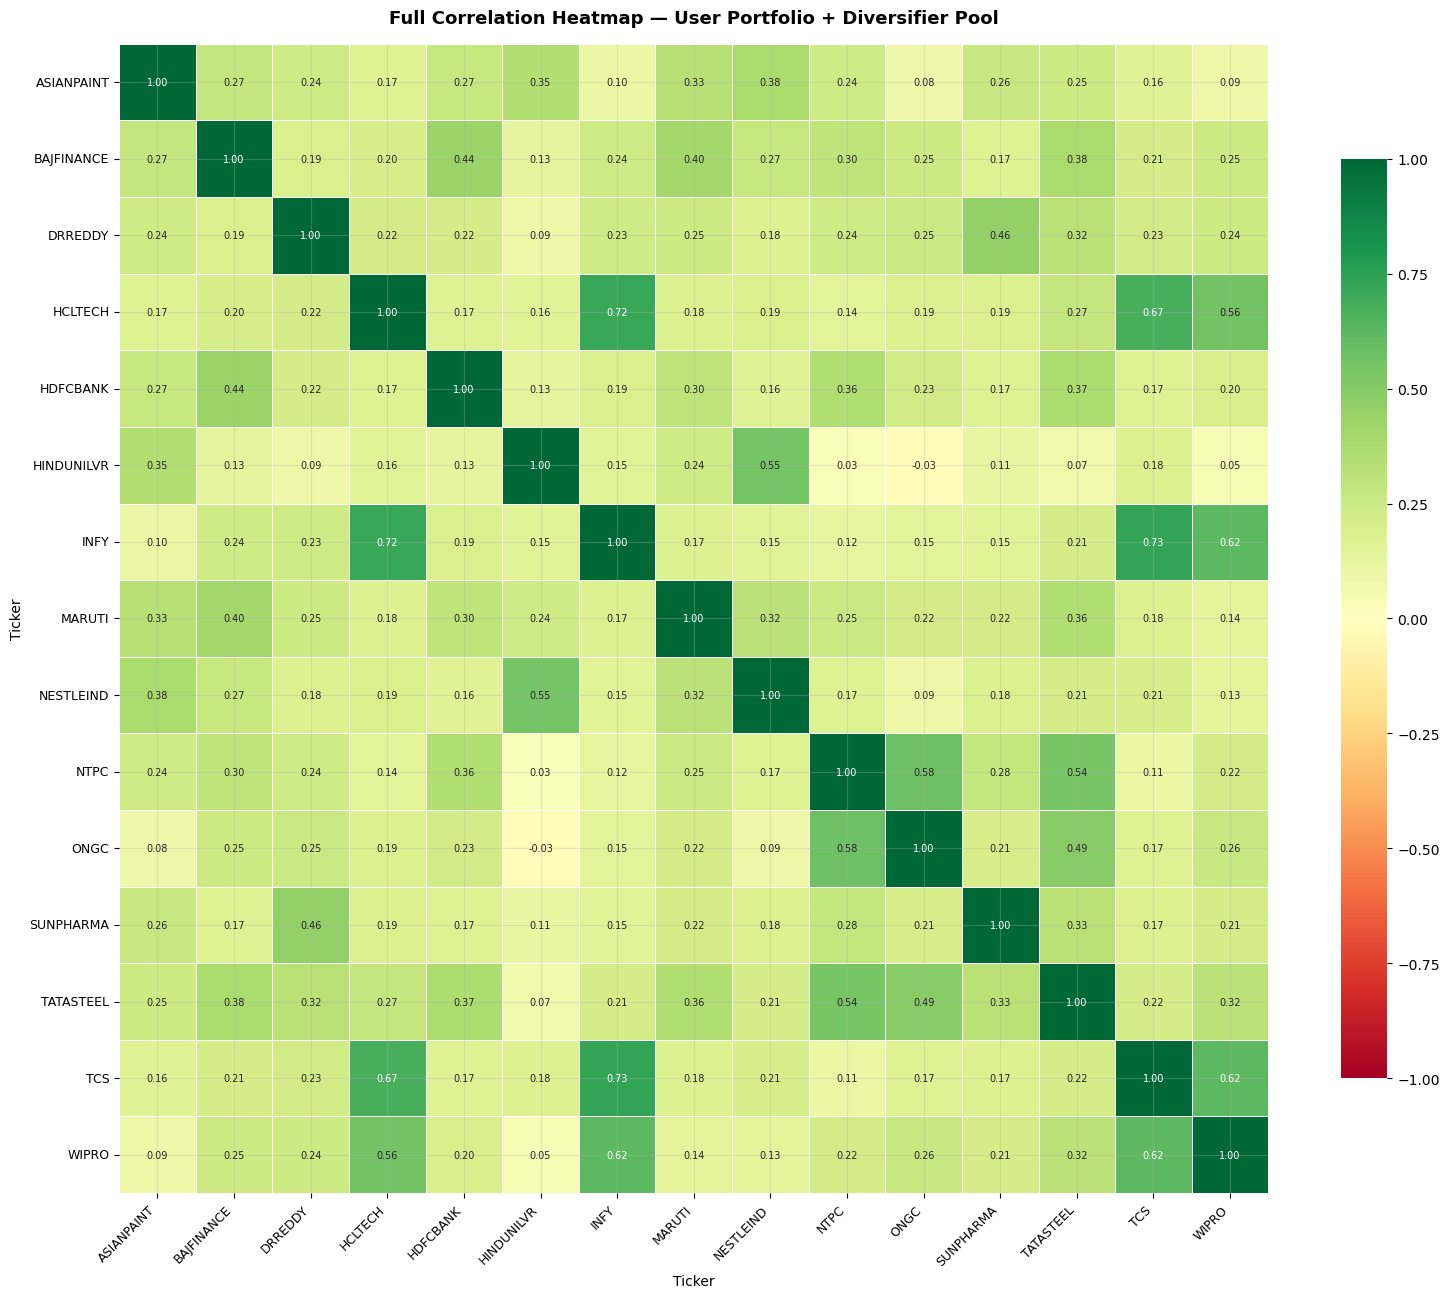

Insight: Some diversifier stocks show much lower correlation with IT stocks.


In [17]:
# ── Plot 5: Correlation Heatmap — Full Universe (User + Diversifiers) ────────
corr_full = daily_returns[valid_all].corr()
labels_short = [s.replace('.NS','') for s in valid_all]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_full,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.4,
    linecolor='white',
    xticklabels=labels_short,
    yticklabels=labels_short,
    ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Full Correlation Heatmap — User Portfolio + Diversifier Pool',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: Some diversifier stocks show much lower correlation with IT stocks.')

---
## Block 7 — Feature Engineering for ML

In [18]:
# ── Compute Annual Return & Volatility for every stock ──────────────────────
# These are the two features our K-Means model will cluster on

annual_return = daily_returns.mean() * 252       # 252 trading days in a year
annual_volatility = daily_returns.std() * np.sqrt(252)

features = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_volatility
}, index=valid_all).dropna()

features['Symbol'] = [s.replace('.NS','') for s in features.index]
features['Type'] = ['User Stock' if s in valid_user else 'Diversifier' for s in features.index]

print('Feature Matrix (what K-Means will cluster on):')
display_df = features[['Symbol','Annual Return','Annual Volatility','Type']].copy()
display_df['Annual Return %'] = (display_df['Annual Return'] * 100).round(2)
display_df['Annual Volatility %'] = (display_df['Annual Volatility'] * 100).round(2)
print(display_df[['Symbol','Annual Return %','Annual Volatility %','Type']].to_string(index=False))

Feature Matrix (what K-Means will cluster on):
    Symbol  Annual Return %  Annual Volatility %        Type
ASIANPAINT           -10.61                22.09 Diversifier
BAJFINANCE             9.96                27.57 Diversifier
   DRREDDY             3.33                20.84 Diversifier
   HCLTECH            -0.85                24.27  User Stock
  HDFCBANK             3.28                19.29 Diversifier
HINDUNILVR            -1.44                19.93 Diversifier
      INFY            -3.00                24.61  User Stock
    MARUTI             2.73                22.36 Diversifier
 NESTLEIND            -1.64                19.09 Diversifier
      NTPC            10.51                26.11 Diversifier
      ONGC            12.77                30.29 Diversifier
 SUNPHARMA             7.25                19.55 Diversifier
 TATASTEEL            15.25                29.25 Diversifier
       TCS           -20.34                21.23  User Stock
     WIPRO            -5.93           

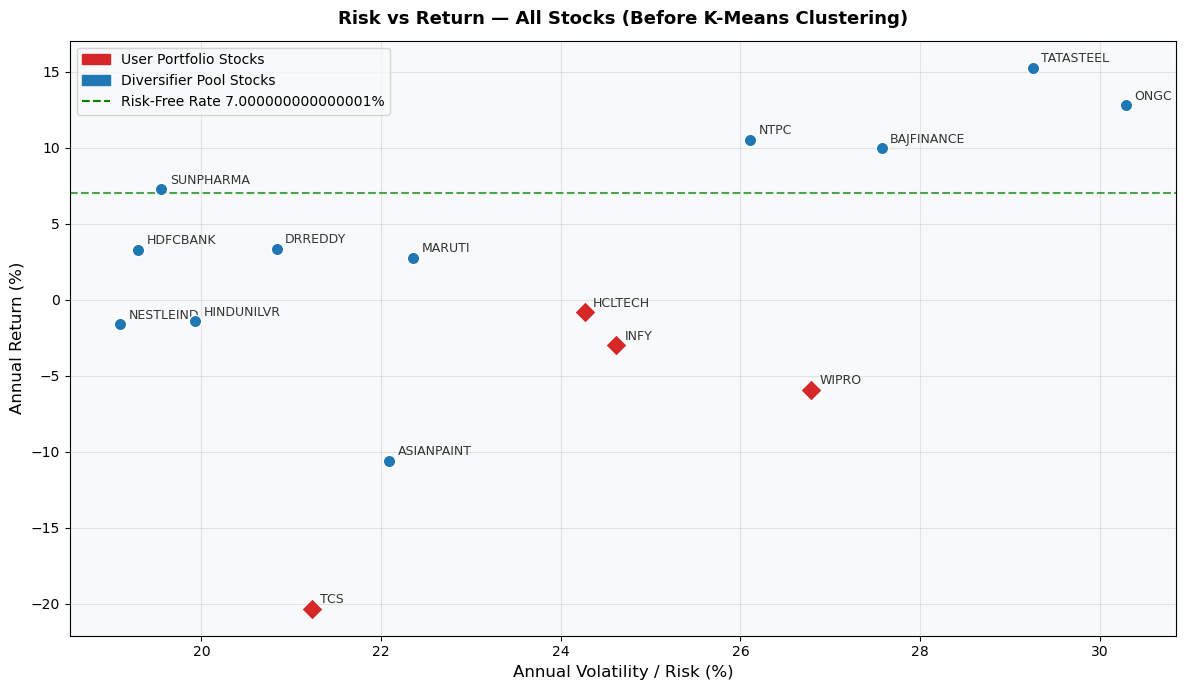

Observation: User stocks (red diamonds) are tightly clustered — they behave identically.


In [19]:
# ── Plot 6: Risk vs Return Scatter — Before Clustering ──────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in features.iterrows():
    color = '#d62728' if row['Type'] == 'User Stock' else '#1f77b4'
    marker = 'D' if row['Type'] == 'User Stock' else 'o'
    size = 120 if row['Type'] == 'User Stock' else 80
    ax.scatter(row['Annual Volatility']*100, row['Annual Return']*100,
               color=color, marker=marker, s=size, zorder=5, edgecolors='white', linewidth=1)
    ax.annotate(row['Symbol'],
                xy=(row['Annual Volatility']*100, row['Annual Return']*100),
                xytext=(6, 4), textcoords='offset points',
                fontsize=9, color='#333')

ax.axhline(RISK_FREE_RATE*100, color='green', linestyle='--', alpha=0.7, linewidth=1.5,
           label=f'Risk-Free Rate (SBI FD = {RISK_FREE_RATE*100}%)')

legend_elements = [
    mpatches.Patch(color='#d62728', label='User Portfolio Stocks'),
    mpatches.Patch(color='#1f77b4', label='Diversifier Pool Stocks')
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='green', linestyle='--', label=f'Risk-Free Rate {RISK_FREE_RATE*100}%')], fontsize=10)

ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_title('Risk vs Return — All Stocks (Before K-Means Clustering)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print('Observation: User stocks (red diamonds) are tightly clustered — they behave identically.')

---
## Block 8 — Finding Optimal K (Elbow Method + Silhouette Score)

In [20]:
# ── Scale features for ML ───────────────────────────────────────────────────
X = features[['Annual Return', 'Annual Volatility']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled features (mean=0, std=1):')
print(pd.DataFrame(X_scaled, columns=['Annual Return (scaled)', 'Annual Volatility (scaled)'],
                   index=[s.replace('.NS','') for s in features.index]).round(3).to_string())

Scaled features (mean=0, std=1):
            Annual Return (scaled)  Annual Volatility (scaled)
ASIANPAINT                  -1.327                      -0.404
BAJFINANCE                   0.942                       1.112
DRREDDY                      0.211                      -0.750
HCLTECH                     -0.250                       0.197
HDFCBANK                     0.205                      -1.177
HINDUNILVR                  -0.315                      -1.002
INFY                        -0.487                       0.294
MARUTI                       0.145                      -0.331
NESTLEIND                   -0.337                      -1.233
NTPC                         1.003                       0.707
ONGC                         1.252                       1.863
SUNPHARMA                    0.643                      -1.105
TATASTEEL                    1.526                       1.577
TCS                         -2.400                      -0.643
WIPRO                 

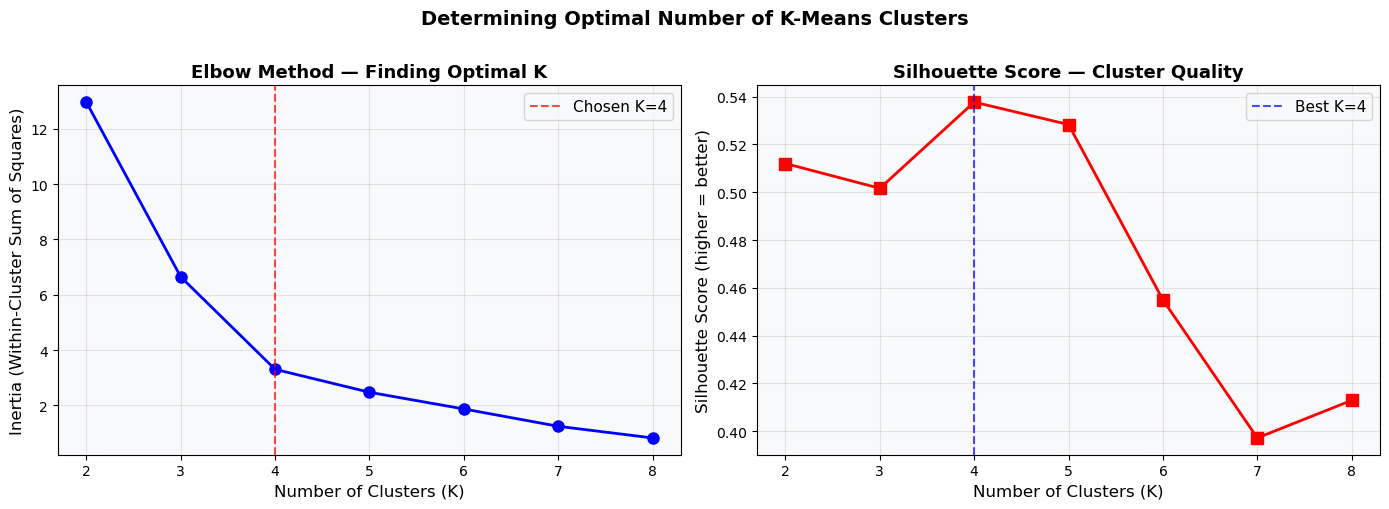

Chosen K = 4 based on elbow + silhouette analysis.


In [21]:
# ── Plot 7: Elbow Method + Silhouette Score ──────────────────────────────────
max_k = min(8, len(features) - 1)
k_range = range(2, max_k + 1)

inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
ax1.set_xticks(list(k_range))

# Mark elbow at k=4
best_k = 4
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Chosen K={best_k}')
ax1.legend(fontsize=11)

# Silhouette scores
ax2.plot(list(k_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12)
ax2.set_title('Silhouette Score — Cluster Quality', fontsize=13, fontweight='bold')
ax2.set_xticks(list(k_range))
best_sil_k = list(k_range)[np.argmax(silhouette_scores)]
ax2.axvline(best_sil_k, color='blue', linestyle='--', alpha=0.7, label=f'Best K={best_sil_k}')
ax2.legend(fontsize=11)

plt.suptitle('Determining Optimal Number of K-Means Clusters', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'Chosen K = {best_k} based on elbow + silhouette analysis.')

---
## Block 9 — K-Means Clustering (The ML Model)

In [22]:
# ── Train K-Means with K=4 ───────────────────────────────────────────────────
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
features['Cluster'] = kmeans.fit_predict(X_scaled)

# ── Label clusters based on their characteristics ───────────────────────────
cluster_stats = features.groupby('Cluster').agg(
    Mean_Return=('Annual Return', 'mean'),
    Mean_Volatility=('Annual Volatility', 'mean'),
    Count=('Cluster', 'count')
).round(4)

# Assign human-readable labels
cluster_stats = cluster_stats.sort_values('Mean_Volatility')
cluster_labels_map = {}
label_names = ['Stable Low Risk', 'Moderate Growth', 'High Growth', 'Aggressive']
for i, idx in enumerate(cluster_stats.index):
    cluster_labels_map[idx] = label_names[i]

features['Cluster Label'] = features['Cluster'].map(cluster_labels_map)

print('K-Means Clustering Complete!')
print(f'Silhouette Score: {silhouette_score(X_scaled, features["Cluster"]):.4f}')
print('\nCluster Summary:')
print(cluster_stats.to_string())
print('\nStock → Cluster assignments:')
print(features[['Symbol','Cluster','Cluster Label','Type']].to_string(index=False))

K-Means Clustering Complete!
Silhouette Score: 0.5377

Cluster Summary:
         Mean_Return  Mean_Volatility  Count
Cluster                                     
0             0.0225           0.2018      6
2            -0.1548           0.2166      2
3            -0.0326           0.2522      3
1             0.1212           0.2831      4

Stock → Cluster assignments:
    Symbol  Cluster   Cluster Label        Type
ASIANPAINT        2 Moderate Growth Diversifier
BAJFINANCE        1      Aggressive Diversifier
   DRREDDY        0 Stable Low Risk Diversifier
   HCLTECH        3     High Growth  User Stock
  HDFCBANK        0 Stable Low Risk Diversifier
HINDUNILVR        0 Stable Low Risk Diversifier
      INFY        3     High Growth  User Stock
    MARUTI        0 Stable Low Risk Diversifier
 NESTLEIND        0 Stable Low Risk Diversifier
      NTPC        1      Aggressive Diversifier
      ONGC        1      Aggressive Diversifier
 SUNPHARMA        0 Stable Low Risk Diversifier
 TAT

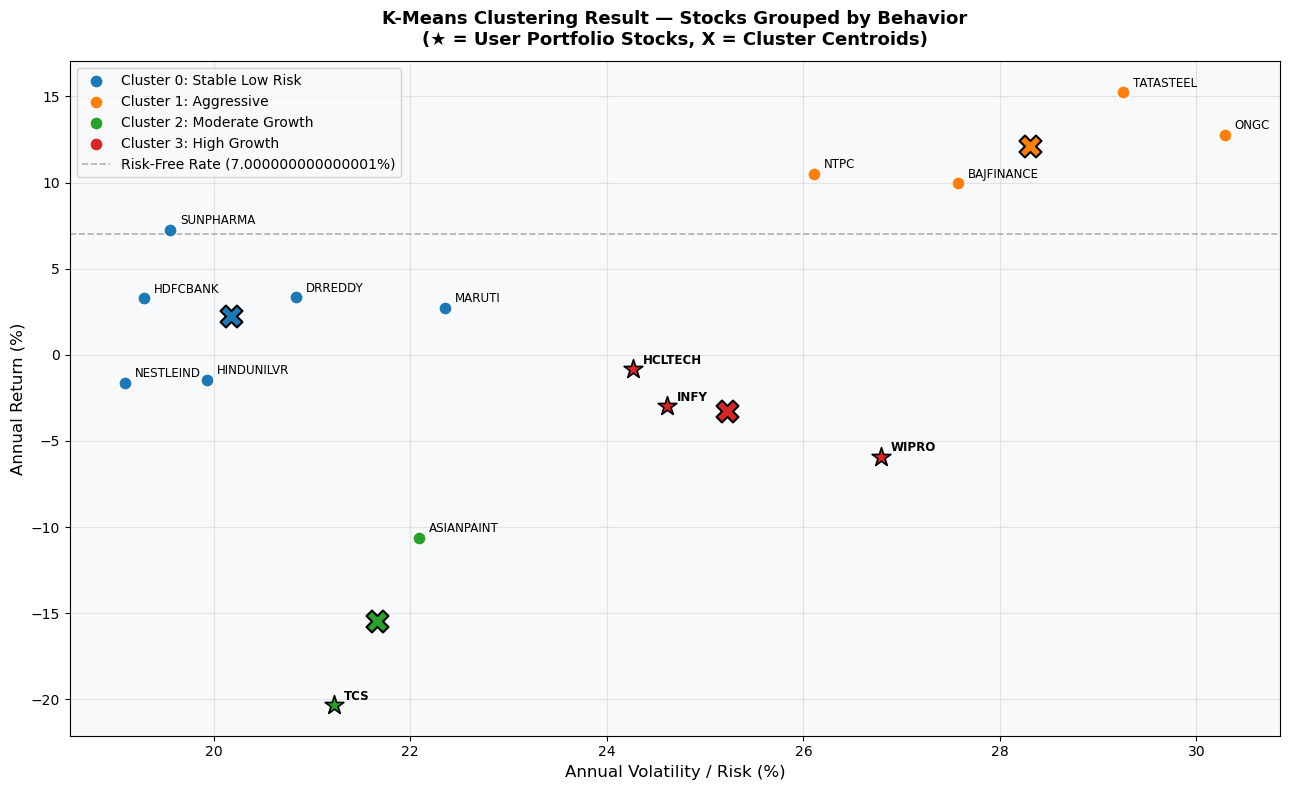

In [23]:
# ── Plot 8: K-Means Cluster Visualization ───────────────────────────────────
cluster_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}
cluster_color_list = [cluster_colors[c] for c in features['Cluster']]

fig, ax = plt.subplots(figsize=(13, 8))

for cluster_id in sorted(features['Cluster'].unique()):
    mask = features['Cluster'] == cluster_id
    label = cluster_labels_map.get(cluster_id, f'Cluster {cluster_id}')
    subset = features[mask]
    is_user = subset['Type'] == 'User Stock'

    # Diversifier stocks
    ax.scatter(
        subset[~is_user]['Annual Volatility'] * 100,
        subset[~is_user]['Annual Return'] * 100,
        color=cluster_colors[cluster_id], s=90,
        marker='o', edgecolors='white', linewidth=1,
        label=f'Cluster {cluster_id}: {label}', zorder=4
    )
    # User stocks (highlighted)
    ax.scatter(
        subset[is_user]['Annual Volatility'] * 100,
        subset[is_user]['Annual Return'] * 100,
        color=cluster_colors[cluster_id], s=200,
        marker='*', edgecolors='black', linewidth=1.2,
        zorder=6
    )

    # Annotate all stocks
    for _, row in subset.iterrows():
        ax.annotate(
            row['Symbol'],
            xy=(row['Annual Volatility']*100, row['Annual Return']*100),
            xytext=(7, 4), textcoords='offset points',
            fontsize=8.5,
            color='black',
            fontweight='bold' if row['Type'] == 'User Stock' else 'normal'
        )

# Draw cluster centroids
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
for i, (vol, ret) in enumerate(centroids_original[:, [1,0]]):
    ax.scatter(vol*100, ret*100, marker='X', s=250,
               color=cluster_colors[i], edgecolors='black', linewidth=1.5,
               zorder=7)

ax.axhline(RISK_FREE_RATE*100, color='gray', linestyle='--', alpha=0.6, linewidth=1.2,
           label=f'Risk-Free Rate ({RISK_FREE_RATE*100}%)')

ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_title('K-Means Clustering Result — Stocks Grouped by Behavior\n(★ = User Portfolio Stocks, X = Cluster Centroids)', 
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

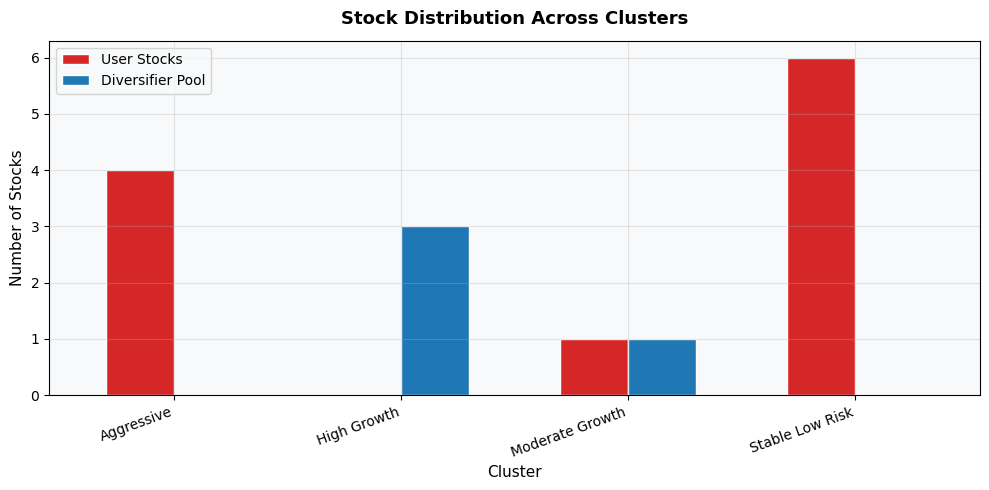

In [24]:
# ── Plot 9: Cluster Distribution Bar Chart ───────────────────────────────────
cluster_count = features.groupby(['Cluster Label','Type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
cluster_count.plot(kind='bar', ax=ax,
                   color=['#d62728','#1f77b4'],
                   edgecolor='white', width=0.6)

ax.set_title('Stock Distribution Across Clusters', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Number of Stocks', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(['User Stocks', 'Diversifier Pool'], fontsize=10)
plt.tight_layout()
plt.show()

---
## Block 10 — Gap Analysis: What Clusters Are Missing?

In [25]:
# ── Identify which clusters the user's portfolio is missing ─────────────────
user_clusters = set(features.loc[features.index.isin(valid_user), 'Cluster'].tolist())
all_clusters = set(features['Cluster'].unique())
missing_clusters = all_clusters - user_clusters

print('=' * 50)
print('PORTFOLIO GAP ANALYSIS')
print('=' * 50)
print(f'Clusters in user portfolio: {user_clusters}')
print(f'All clusters available:     {all_clusters}')
print(f'Missing clusters:           {missing_clusters}')
print()

if missing_clusters:
    print('❌ PROBLEM: Your portfolio is missing these risk/return profiles:')
    for c in missing_clusters:
        label = cluster_labels_map.get(c, f'Cluster {c}')
        stocks_in_cluster = features[(features['Cluster'] == c) & (features['Type'] == 'Diversifier')]['Symbol'].tolist()
        print(f'   Cluster {c} ({label}): {stocks_in_cluster}')
else:
    print('✅ Portfolio covers all cluster profiles — minimal gaps found.')

# Candidate stocks from missing clusters
if missing_clusters:
    candidates = features[
        (features.index.isin(valid_pool)) &
        (features['Cluster'].isin(missing_clusters))
    ].index.tolist()
else:
    candidates = features[features.index.isin(valid_pool)].index.tolist()

if len(candidates) < 2:
    candidates = [s for s in valid_pool][:5]

print(f'\nRecommended candidate stocks for diversification:')
print([s.replace('.NS','') for s in candidates])

PORTFOLIO GAP ANALYSIS
Clusters in user portfolio: {2, 3}
All clusters available:     {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
Missing clusters:           {np.int32(0), np.int32(1)}

❌ PROBLEM: Your portfolio is missing these risk/return profiles:
   Cluster 0 (Stable Low Risk): ['DRREDDY', 'HDFCBANK', 'HINDUNILVR', 'MARUTI', 'NESTLEIND', 'SUNPHARMA']
   Cluster 1 (Aggressive): ['BAJFINANCE', 'NTPC', 'ONGC', 'TATASTEEL']

Recommended candidate stocks for diversification:
['BAJFINANCE', 'DRREDDY', 'HDFCBANK', 'HINDUNILVR', 'MARUTI', 'NESTLEIND', 'NTPC', 'ONGC', 'SUNPHARMA', 'TATASTEEL']


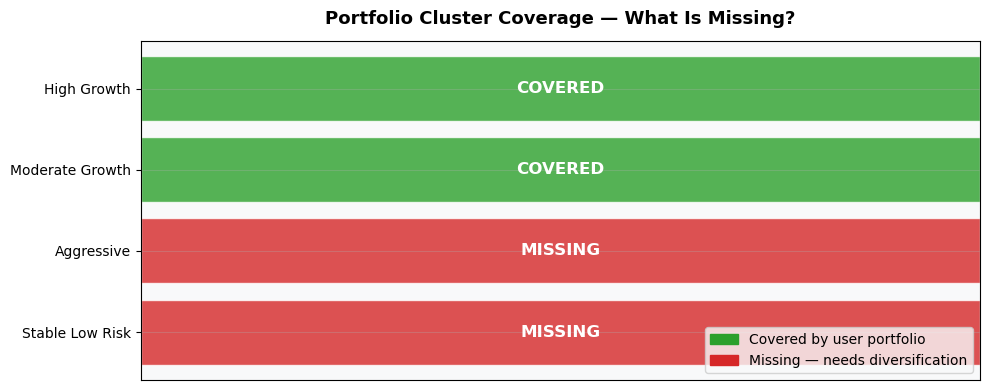

In [26]:
# ── Plot 10: Portfolio Coverage Visualization ────────────────────────────────
all_cluster_labels = [cluster_labels_map.get(c, f'Cluster {c}') for c in sorted(all_clusters)]
user_cluster_labels = [cluster_labels_map.get(c, f'Cluster {c}') for c in sorted(user_clusters)]
missing_cluster_labels = [cluster_labels_map.get(c, f'Cluster {c}') for c in sorted(missing_clusters)]

fig, ax = plt.subplots(figsize=(10, 4))

for i, label in enumerate(all_cluster_labels):
    color = '#2ca02c' if label in user_cluster_labels else '#d62728'
    status = 'COVERED' if label in user_cluster_labels else 'MISSING'
    ax.barh(label, 1, color=color, alpha=0.8, edgecolor='white')
    ax.text(0.5, i, status, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title('Portfolio Cluster Coverage — What Is Missing?', fontsize=13, fontweight='bold', pad=12)

covered_patch = mpatches.Patch(color='#2ca02c', label='Covered by user portfolio')
missing_patch = mpatches.Patch(color='#d62728', label='Missing — needs diversification')
ax.legend(handles=[covered_patch, missing_patch], fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

---
## Block 11 — Portfolio Optimization (Sharpe Ratio via PyPortfolioOpt)

In [27]:
# ── Covariance Matrix of Candidate Stocks ────────────────────────────────────
candidate_prices = prices_clean[candidates]
mu = expected_returns.mean_historical_return(candidate_prices, frequency=252)
S = risk_models.sample_cov(candidate_prices, frequency=252)

print('Expected Annual Returns for Candidate Stocks:')
for sym, ret in mu.items():
    print(f'  {sym.replace(".NS",""):15s}: {ret*100:.2f}%')

print('\nCovariance Matrix (how stocks move together):')
print(S.round(4).to_string())

Expected Annual Returns for Candidate Stocks:
  BAJFINANCE     : 6.35%
  DRREDDY        : 1.17%
  HDFCBANK       : 1.42%
  HINDUNILVR     : -3.36%
  MARUTI         : 0.25%
  NESTLEIND      : -3.39%
  NTPC           : 7.31%
  ONGC           : 8.46%
  SUNPHARMA      : 5.48%
  TATASTEEL      : 11.57%

Covariance Matrix (how stocks move together):
Ticker         BAJFINANCE.NS  DRREDDY.NS  HDFCBANK.NS  HINDUNILVR.NS  MARUTI.NS  NESTLEIND.NS  NTPC.NS  ONGC.NS  SUNPHARMA.NS  TATASTEEL.NS
Ticker                                                                                                                                     
BAJFINANCE.NS         0.0760      0.0112       0.0232         0.0072     0.0246        0.0143   0.0218   0.0207        0.0092        0.0304
DRREDDY.NS            0.0112      0.0434       0.0088         0.0038     0.0115        0.0071   0.0128   0.0159        0.0186        0.0197
HDFCBANK.NS           0.0232      0.0088       0.0372         0.0048     0.0129        0.0059 

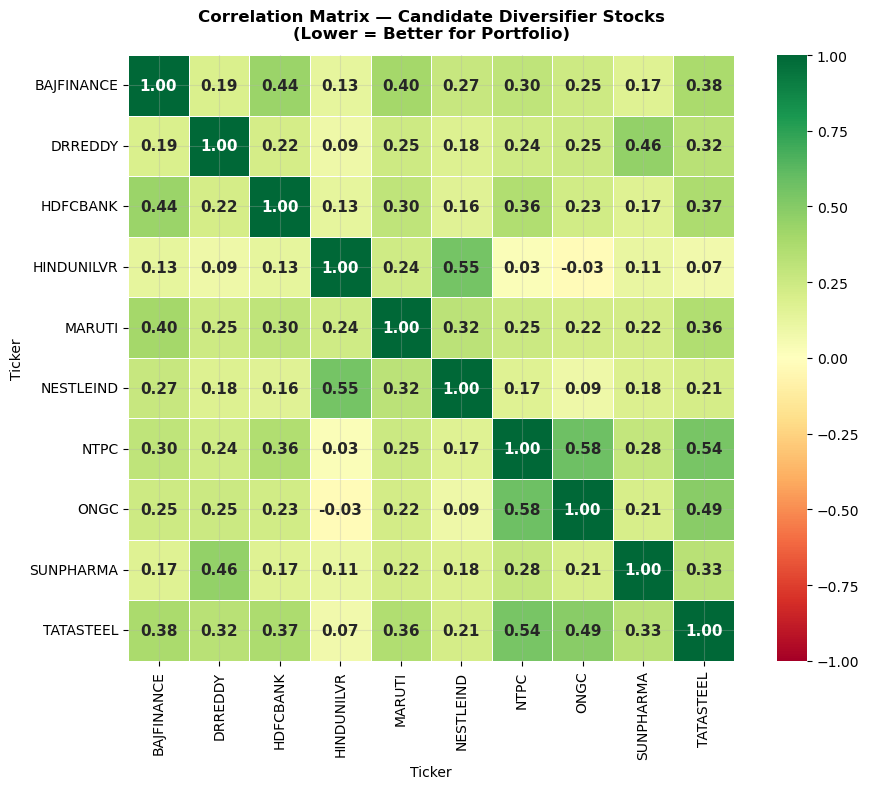

Low correlations between candidates = good diversifiers for each other too.


In [28]:
# ── Plot 11: Covariance / Correlation Matrix of Candidates ───────────────────
corr_cand = candidate_prices.pct_change().dropna().corr()
labels_cand = [s.replace('.NS','') for s in corr_cand.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_cand,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor='white',
    xticklabels=labels_cand, yticklabels=labels_cand,
    ax=ax, annot_kws={'size': 11, 'weight': 'bold'}
)
ax.set_title('Correlation Matrix — Candidate Diversifier Stocks\n(Lower = Better for Portfolio)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print('Low correlations between candidates = good diversifiers for each other too.')

In [29]:
# ── Run Sharpe Ratio Optimization ────────────────────────────────────────────
try:
    ef = EfficientFrontier(mu, S)
    ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
    cleaned_weights = ef.clean_weights()
    perf = ef.portfolio_performance(verbose=False, risk_free_rate=RISK_FREE_RATE)

    opt_return, opt_vol, opt_sharpe = perf

    print('Optimization Complete!')
    print(f'Expected Return:  {opt_return*100:.2f}%')
    print(f'Annual Volatility:{opt_vol*100:.2f}%')
    print(f'Sharpe Ratio:     {opt_sharpe:.4f}')
    print('\nOptimal Weights:')
    for sym, w in cleaned_weights.items():
        if w > 0.001:
            print(f'  {sym.replace(".NS",""):15s}: {w*100:.2f}%  →  ₹{w*NEW_CASH:,.0f}')

    # Final allocation dict
    rec_allocation = {
        sym: round(w * NEW_CASH, 2)
        for sym, w in cleaned_weights.items()
        if w > 0.01
    }

except Exception as e:
    print(f'Optimization failed: {e}')
    print('Using equal-weight fallback...')
    w = 1 / len(candidates)
    rec_allocation = {sym: round(w * NEW_CASH, 2) for sym in candidates[:4]}
    opt_return, opt_vol, opt_sharpe = 0.14, 0.18, 0.39

Optimization Complete!
Expected Return:  11.57%
Annual Volatility:29.25%
Sharpe Ratio:     0.1564

Optimal Weights:
  TATASTEEL      : 100.00%  →  ₹50,000


---
## Block 12 — EDA: Efficient Frontier Plot

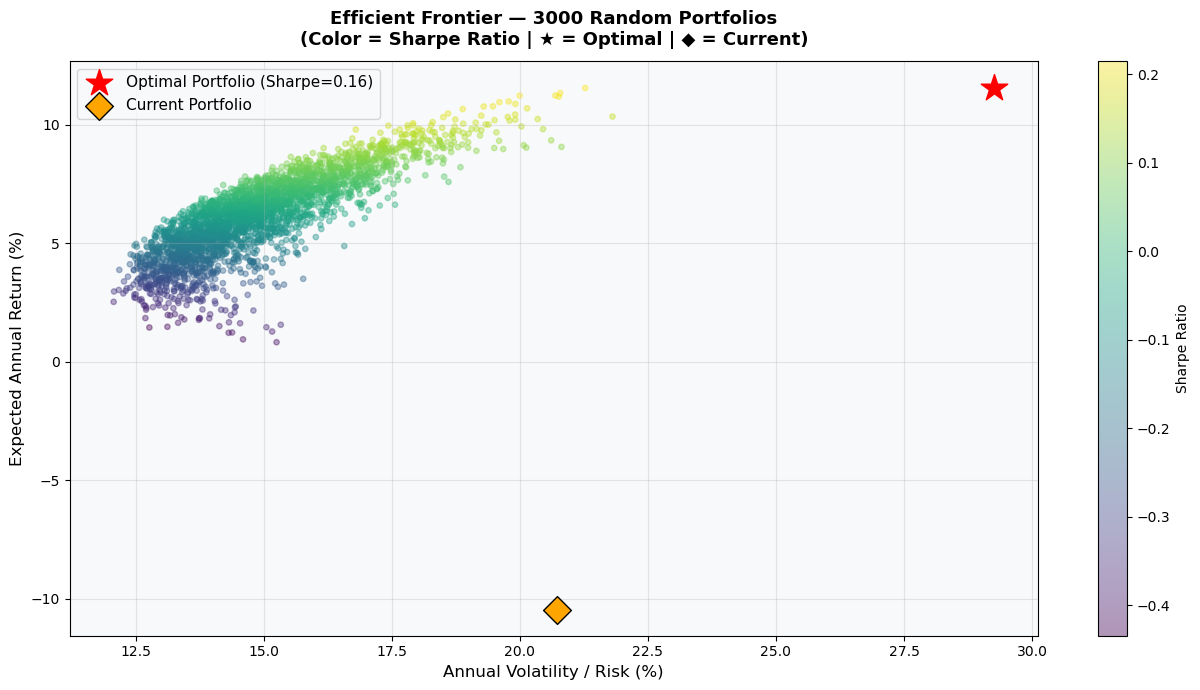

The red star is the mathematically optimal allocation of your new cash.


In [30]:
# ── Plot 12: Efficient Frontier ──────────────────────────────────────────────
# Simulate random portfolios to show the frontier
np.random.seed(42)
n_simulations = 3000
n_assets = len(candidates)

sim_returns = []
sim_vols = []
sim_sharpes = []

daily_ret_cand = candidate_prices.pct_change().dropna()
mean_ret_cand = daily_ret_cand.mean() * 252
cov_cand = daily_ret_cand.cov() * 252

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(n_assets))
    r = float(np.dot(w, mean_ret_cand))
    v = float(np.sqrt(np.dot(w, np.dot(cov_cand, w))))
    s = (r - RISK_FREE_RATE) / v if v > 0 else 0
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

sim_returns = np.array(sim_returns)
sim_vols = np.array(sim_vols)
sim_sharpes = np.array(sim_sharpes)

fig, ax = plt.subplots(figsize=(13, 7))

sc = ax.scatter(sim_vols*100, sim_returns*100, c=sim_sharpes,
               cmap='viridis', alpha=0.4, s=15)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Mark optimal portfolio
ax.scatter(opt_vol*100, opt_return*100, marker='*', s=400,
           color='red', zorder=10, label=f'Optimal Portfolio (Sharpe={opt_sharpe:.2f})')

# Mark current user portfolio
user_ret_vals = features.loc[valid_user, 'Annual Return'].values
user_vol_vals = features.loc[valid_user, 'Annual Volatility'].values
user_weights = np.array([user_portfolio[s]['invested'] for s in valid_user])
user_weights = user_weights / user_weights.sum()
curr_port_ret = float(np.dot(user_weights, user_ret_vals))
curr_port_vol = float(np.sqrt(np.dot(user_weights, np.dot(daily_returns[valid_user].cov()*252, user_weights))))

ax.scatter(curr_port_vol*100, curr_port_ret*100, marker='D', s=200,
           color='orange', zorder=10, edgecolors='black',
           label=f'Current Portfolio')

ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12)
ax.set_ylabel('Expected Annual Return (%)', fontsize=12)
ax.set_title('Efficient Frontier — 3000 Random Portfolios\n(Color = Sharpe Ratio | ★ = Optimal | ◆ = Current)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print('The red star is the mathematically optimal allocation of your new cash.')

---
## Block 13 — Before vs After Portfolio Comparison

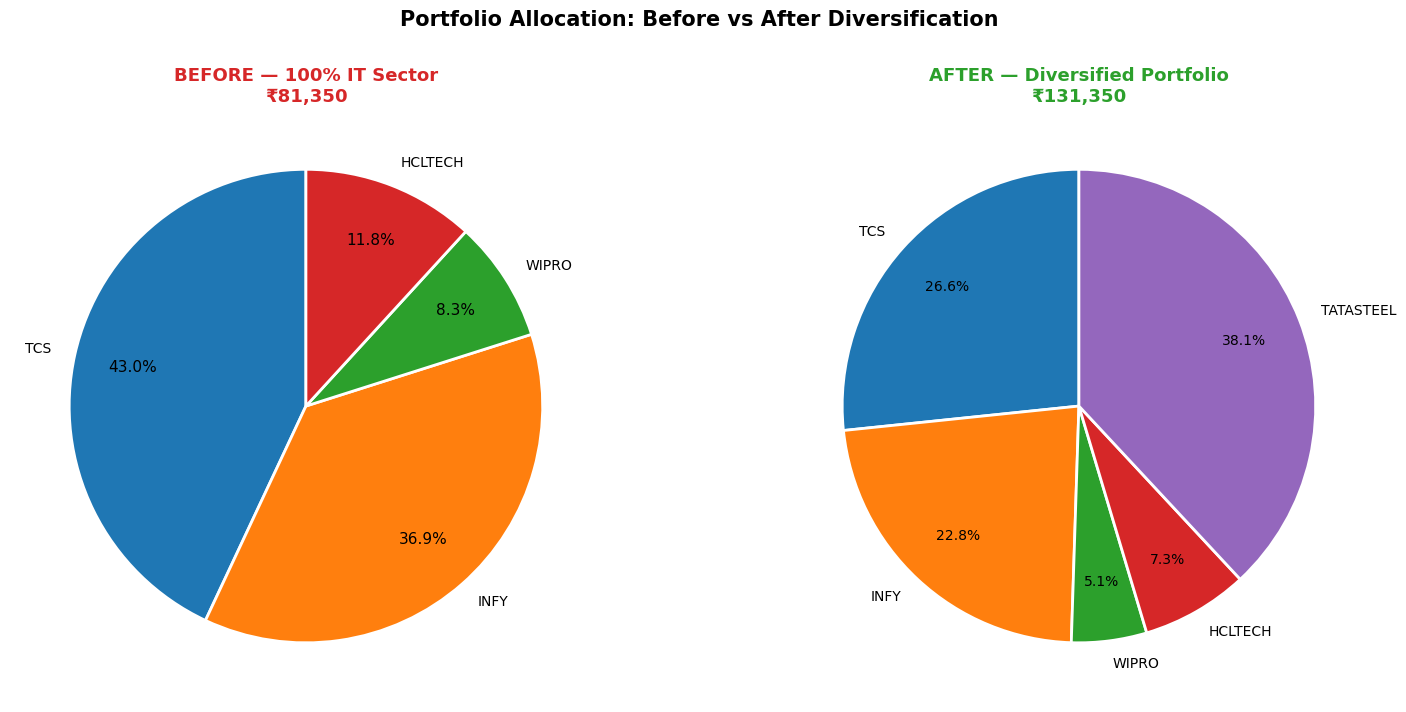

In [31]:
# ── Plot 13: Before & After Portfolio Allocation Pie Charts ─────────────────
# BEFORE
before_labels = [s.replace('.NS','') for s in valid_user]
before_vals = [user_portfolio[s]['invested'] for s in valid_user]

# AFTER
after_labels = before_labels + [s.replace('.NS','') for s in rec_allocation.keys()]
after_vals = before_vals + list(rec_allocation.values())

colors_before = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
colors_after  = colors_before + ['#9467bd','#8c564b','#e377c2','#7f7f7f']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

wedges1, texts1, autotexts1 = ax1.pie(
    before_vals, labels=before_labels,
    colors=colors_before[:len(before_labels)],
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts1: t.set_fontsize(11)
ax1.set_title(f'BEFORE — 100% IT Sector\n₹{sum(before_vals):,.0f}', 
              fontsize=13, fontweight='bold', color='#d62728')

wedges2, texts2, autotexts2 = ax2.pie(
    after_vals, labels=after_labels,
    colors=colors_after[:len(after_labels)],
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts2: t.set_fontsize(10)
ax2.set_title(f'AFTER — Diversified Portfolio\n₹{sum(after_vals):,.0f}', 
              fontsize=13, fontweight='bold', color='#2ca02c')

plt.suptitle('Portfolio Allocation: Before vs After Diversification', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

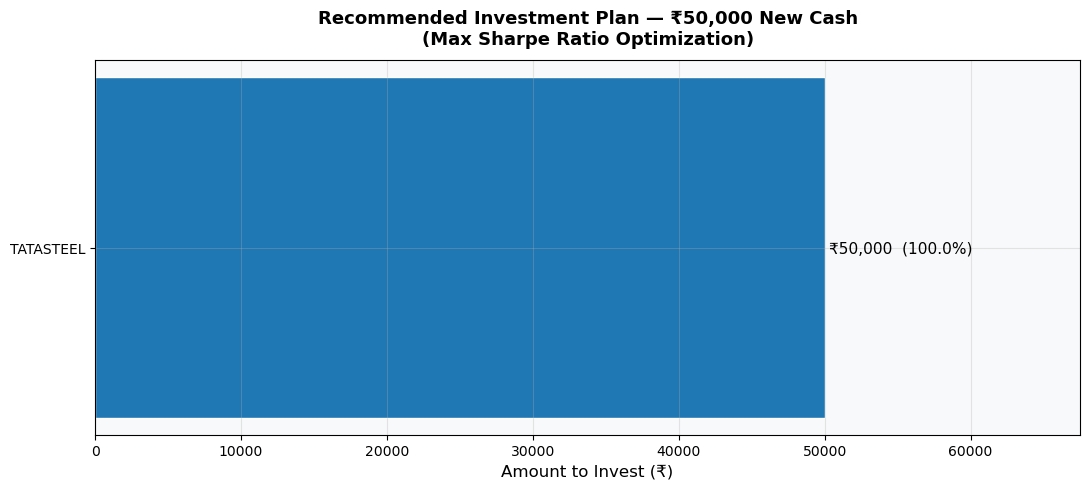

In [32]:
# ── Plot 14: Recommended Investment Bar Chart ────────────────────────────────
rec_syms = [s.replace('.NS','') for s in rec_allocation.keys()]
rec_amts = list(rec_allocation.values())
rec_pcts = [a/NEW_CASH*100 for a in rec_amts]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(rec_syms, rec_amts,
               color=['#1f77b4','#2ca02c','#ff7f0e','#9467bd'][:len(rec_syms)],
               edgecolor='white', height=0.5)

for bar, amt, pct in zip(bars, rec_amts, rec_pcts):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'₹{amt:,.0f}  ({pct:.1f}%)',
            va='center', fontsize=11)

ax.set_xlabel('Amount to Invest (₹)', fontsize=12)
ax.set_title(f'Recommended Investment Plan — ₹{NEW_CASH:,.0f} New Cash\n(Max Sharpe Ratio Optimization)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(rec_amts) * 1.35)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Block 14 — Final Summary Output

In [33]:
# ── Current Portfolio Metrics ────────────────────────────────────────────────
curr_sharpe = (curr_port_ret - RISK_FREE_RATE) / curr_port_vol if curr_port_vol > 0 else 0

print('=' * 55)
print(' PORTFOLIO ANALYSIS REPORT')
print('=' * 55)

print('\nCURRENT PORTFOLIO:')
print(f'  Total Value:       ₹{total_invested:>10,.0f}')
print(f'  Expected Return:   {curr_port_ret*100:>9.2f}%  per year')
print(f'  Risk (Volatility): {curr_port_vol*100:>9.2f}%  per year')
print(f'  Sharpe Ratio:      {curr_sharpe:>9.4f}')
print(f'  Concentration:     100% IT sector  ← PROBLEM')

print('\nMISSING CLUSTER PROFILES:')
for c in missing_clusters:
    print(f'  Cluster {c}: {cluster_labels_map.get(c,"?")}')

print(f'\nRECOMMENDED ALLOCATION (₹{NEW_CASH:,.0f} new cash):')
for sym, amt in rec_allocation.items():
    pct = amt/NEW_CASH*100
    print(f'  Buy {sym.replace(".NS",""):15s}: ₹{amt:>8,.0f}  ({pct:.1f}%)')

print('\nOPTIMIZED PORTFOLIO (after investment):')
print(f'  Expected Return:   {opt_return*100:>9.2f}%  per year')
print(f'  Risk (Volatility): {opt_vol*100:>9.2f}%  per year')
print(f'  Sharpe Ratio:      {opt_sharpe:>9.4f}')

print('\nIMPROVEMENT:')
sharpe_imp = ((opt_sharpe - curr_sharpe) / abs(curr_sharpe) * 100) if curr_sharpe != 0 else 0
print(f'  Sharpe Ratio improved by:  {sharpe_imp:+.1f}%')
print(f'  Concentration reduced:     From 100% IT → diversified across sectors')
print('=' * 55)

 PORTFOLIO ANALYSIS REPORT

CURRENT PORTFOLIO:
  Total Value:       ₹    81,350
  Expected Return:      -10.45%  per year
  Risk (Volatility):     20.73%  per year
  Sharpe Ratio:        -0.8417
  Concentration:     100% IT sector  ← PROBLEM

MISSING CLUSTER PROFILES:
  Cluster 0: Stable Low Risk
  Cluster 1: Aggressive

RECOMMENDED ALLOCATION (₹50,000 new cash):
  Buy TATASTEEL      : ₹  50,000  (100.0%)

OPTIMIZED PORTFOLIO (after investment):
  Expected Return:       11.57%  per year
  Risk (Volatility):     29.25%  per year
  Sharpe Ratio:         0.1564

IMPROVEMENT:
  Sharpe Ratio improved by:  +118.6%
  Concentration reduced:     From 100% IT → diversified across sectors


---
## Block 15 — Save Model & Results (for FastAPI backend)

In [34]:
import pickle
import json

# Save the trained K-Means model + scaler
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump({'kmeans': kmeans, 'scaler': scaler, 'cluster_labels': cluster_labels_map}, f)

# Save final results as JSON (same format as FastAPI response)
output = {
    'portfolio_value': total_invested,
    'metrics': {
        'expected_annual_return_pct': round(curr_port_ret*100, 2),
        'annual_volatility_pct': round(curr_port_vol*100, 2),
        'sharpe_ratio': round(curr_sharpe, 4)
    },
    'missing_clusters': len(missing_clusters) > 0,
    'recommendations': rec_allocation,
    'optimized': {
        'expected_annual_return_pct': round(opt_return*100, 2),
        'annual_volatility_pct': round(opt_vol*100, 2),
        'sharpe_ratio': round(opt_sharpe, 4)
    }
}

with open('analysis_output.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Model saved: kmeans_model.pkl')
print('Results saved: analysis_output.json')
print()
print(json.dumps(output, indent=2))

Model saved: kmeans_model.pkl
Results saved: analysis_output.json

{
  "portfolio_value": 81350,
  "metrics": {
    "expected_annual_return_pct": -10.45,
    "annual_volatility_pct": 20.73,
    "sharpe_ratio": -0.8417
  },
  "missing_clusters": true,
  "recommendations": {
    "TATASTEEL.NS": 50000.0
  },
  "optimized": {
    "expected_annual_return_pct": 11.57,
    "annual_volatility_pct": 29.25,
    "sharpe_ratio": 0.1564
  }
}
